In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load the dataset
df = pd.read_csv('creditcard.csv')

# First look at the data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Check the data
print("Dataset Info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nFraud vs Legitimate transactions:")
print(df['Class'].value_counts())

print("\nFraud percentage:")
print(df['Class'].value_counts(normalize=True) * 100)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21    

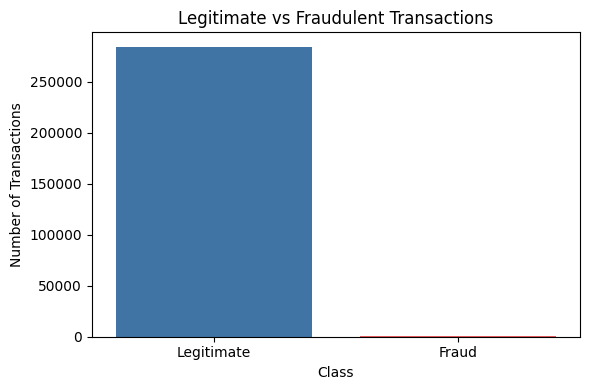

In [6]:
# Visualise fraud vs legitimate 
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, hue='Class', palette={0:'#2E75B6', 1:'#FF4444'}, legend=False)
plt.title('Legitimate vs Fraudulent Transactions')
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

In [7]:
# Scale the Amount column and drop Time
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df = df.drop(['Time', 'Amount'], axis=1)

print("Data ready for modelling!")
print("New shape:", df.shape)

Data ready for modelling!
New shape: (284807, 30)


In [8]:
# Split data into features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Before SMOTE:")
print("Fraud cases in training set:", sum(y_train == 1))
print("Legitimate cases in training set:", sum(y_train == 0))

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("Fraud cases in training set:", sum(y_train_smote == 1))
print("Legitimate cases in training set:", sum(y_train_smote == 0))


Before SMOTE:
Fraud cases in training set: 394
Legitimate cases in training set: 227451

After SMOTE:
Fraud cases in training set: 227451
Legitimate cases in training set: 227451


In [9]:
# Train Logistic Regression model
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)

# Make predictions
lr_predictions = lr_model.predict(X_test)

# Evaluate the model
print("\nLogistic Regression Results:")
print(classification_report(y_test, lr_predictions, target_names=['Legitimate', 'Fraud']))
print("ROC-AUC Score:", roc_auc_score(y_test, lr_predictions))

Training Logistic Regression...

Logistic Regression Results:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC Score: 0.9459151731880147


In [10]:
# Train Random Forest model
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Evaluate
print("\nRandom Forest Results:")
print(classification_report(y_test, rf_predictions, target_names=['Legitimate', 'Fraud']))
print("ROC-AUC Score:", roc_auc_score(y_test, rf_predictions))

Training Random Forest...

Random Forest Results:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9131597912096746


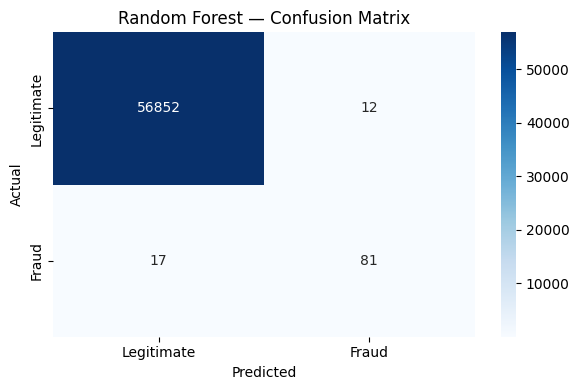

In [11]:
# Confusion matrix for Random Forest
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [13]:
# Summary comparison
print("=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"Logistic Regression - Fraud F1: 0.11 | ROC-AUC: 0.95")
print(f"Random Forest       - Fraud F1: 0.85 | ROC-AUC: 0.91")
print("\nConclusion: Random Forest delivers the best")
print("balance between precision and recall for")
print("real-world fraud detection.")

MODEL COMPARISON SUMMARY
Logistic Regression - Fraud F1: 0.11 | ROC-AUC: 0.95
Random Forest       - Fraud F1: 0.85 | ROC-AUC: 0.91

Conclusion: Random Forest delivers the best
balance between precision and recall for
real-world fraud detection.
